In [7]:
!pip install neurokit2


   ---------------------------------------- 0.0/708.4 kB ? eta -:--:--
   ---------------------------------------- 708.4/708.4 kB 9.7 MB/s  0:00:00


In [14]:
#standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 5 #set the value globally
from IPython import display as disp_img

#SciPy imports
from scipy import signal,ndimage,linalg,fft

#sklearn median absolute error function
from sklearn.metrics import median_absolute_error

#package used to do r-peak detection from ECG
# if not installed locally check instructions from link below
# https://neuropsychology.github.io/NeuroKit/installation.html
import neurokit2 as nk


#py wavelets this package is needed to run the scripts that extract heart rate from bcg signals
# if not installed locally check instructions from link below
# https://pywavelets.readthedocs.io/en/latest/install.html
import pywt

#other stuff
import time
from glob import glob
import os
import gc


# HELPER FUNCTIONS 
* Some functions you may need to use for the exercise

In [15]:
### bp filter function

def bp_filter(signalz,hp=5,lp=35,fs=200,order=4):
    #simple band pass filter function
    #output normalized by standard deviation of signal

    sos = signal.butter(order,[hp,lp],fs=(fs),btype='bandpass',output='sos')
    filtered_signal=signal.sosfiltfilt(sos,signalz,axis=0)
    filtered_signal=filtered_signal/np.std(filtered_signal)
    
    return filtered_signal

### normalize signal between 1 and 0
def normalizesig(data):
    x=np.array(data)
    p1=x-np.min(x)
    p2=np.max(x) - np.min(x)
    
    return 2 * (p1/p2) - 1

### crude rolling max function
def rollingmax(x,window=10):
    arr=np.zeros(x.shape[0])
    
    arr[0:window]=x[0:window]
    arr[-window:]=x[-window:]
    
    for i in range(window,len(x)-window,):
        arr[i]=np.max(x[i-(window//2):i+(window//2)])
        
    return arr

### crude rolling mean function
def rollingmean(x,window=10):
    arr=np.zeros(x.shape[0])
    
    arr[0:window]=x[0:window]
    arr[-window:]=x[-window:]
    
    for i in range(window,len(x)-window,):
        arr[i]=np.mean(x[i-(window//2):i+(window//2)])
        
    return arr

### crude rolling median function
def rollingmedian(x,window=10):
    arr=np.zeros(x.shape[0])
    
    arr[0:window]=x[0:window]
    arr[-window:]=x[-window:]
    
    for i in range(window,len(x)-window,):
        arr[i]=np.median(x[i-(window//2):i+(window//2)])
        
    return arr


### cwt scale selecter function
def scale_selecter(scales=(5,25,.1),fs=200):
    
    #find scales that correlate to given freq range in freq_scales
    all_scales=np.arange(1.5,400,.001)
    freqz=pywt.scale2frequency("morl",all_scales)/ (1/fs)

    goal_scales=[]

    for i in np.arange(scales[0],scales[1]+1,scales[2]):
        index = np.argmin(np.abs(np.array(freqz)-i))
        goal_scales.append(index)

    true_goal=all_scales[sorted(list(set(goal_scales)))]
    goal_freqz=[]
    for i in true_goal:
        goal_freqz.append(pywt.scale2frequency("morl",i)/ (1/fs))

    freqz=pywt.scale2frequency("morl",true_goal)/ (1/fs)
    scalez=true_goal
    
    return scalez

### cwt waveform maker function    
def cwt_waveform_maker(signalz,scalez,wavelet_name="morl",fs=200,abs_val=True):
    dt=1/fs
    
    Zxx, f = pywt.cwt(signalz, scalez, wavelet_name,dt)
    
    if abs_val==True:
        Zxx=np.abs(Zxx)
    else:
        pass
    
    return Zxx,f

### cwt averaging function   
def cwt_stat_waveform(Zxx,smoothwindow=10):
            
    avg_v=np.zeros(Zxx.shape[1])
    avg_v[0:smoothwindow]=np.mean(Zxx[:,0:smoothwindow],axis=0)
    avg_v[-smoothwindow:]=np.mean(Zxx[:,-smoothwindow:],axis=0)
    for i in range(smoothwindow,Zxx.shape[1]-smoothwindow,):
        
        avg_v[i]=np.mean(Zxx[:,i-(smoothwindow):i+(smoothwindow)]) 
            
    N=smoothwindow*2
    avg_v_meanz=rollingmax(avg_v,N)
    N=smoothwindow*4
    avg_v_mean=rollingmean(avg_v_meanz,N)

    return avg_v_mean

###auto corr to HR function
def auto_corr_hr_detector(xc):
    #xc is auto correlation signal
    #find cor peaks 
    fs=200
    cor_pl, properties = signal.find_peaks(xc[25:-25],height=np.percentile(xc,80),distance=75)

    cor_pl=cor_pl+25
    cor_pl = np.insert(cor_pl, 0, 0, axis=0)
    
    if len(cor_pl)>=1:
        if len(cor_pl)==1:
            hr_val=0
        else:
            rrivec=(cor_pl[1]-cor_pl[0])/fs
            
            hr_val=60/rrivec
            
    return hr_val

    


# Data Import 
* Data is from a bed system where sensors capable of measuring BCG signals were placed underneath a mattress to record signals while a person is laying in the bed
* For information on the dataset see the reference paper describing the data:
* https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7795624/

In [16]:
# Example Data view from one patient 
### CHANGE PATH TO YOUR OWN ###
data = pd.read_csv("bcg_exercise_data/sub1.csv")
display(data.head())


,PPG,Resp,HR,ECG,Film0,Film1,Film2,Film3,LC_COP0,LC_BCG0,LC_COP1,LC_BCG1,LC_COP2,LC_BCG2,LC_COP3,LC_BCG3,reBAP,IBI,SV,dp_dt
0,0.254219,1.091090,0.504935,-0.033898,2.962138,3.347859,2.598157,2.917328,1.362734,1.028933,1.259978,1.110529,1.337607,1.029636,1.217102,1.022979,0.805480,1.434846,0.823855,0.802906
1,0.254539,1.091409,0.504616,-0.033898,3.012941,3.369584,2.623391,2.952786,1.362415,1.028614,1.259978,1.110209,1.337926,1.030914,1.400819,1.022660,0.806438,1.436763,0.826730,0.803864
2,0.253900,1.090451,0.503977,-0.033260,3.047128,3.383961,2.638083,2.959174,1.363373,1.028614,1.259658,1.110848,1.338565,1.030914,1.540445,1.023937,0.799731,1.431330,0.822577,0.805780
3,0.246550,1.088854,0.504616,-0.033260,3.070772,3.390031,2.643194,2.938731,1.362415,1.027975,1.259658,1.110209,1.337926,1.031234,1.636297,1.022979,0.808355,1.439959,0.830883,0.805142
4,0.246550,1.088534,0.504616,-0.032940,3.060228,3.386197,2.631056,2.908065,1.362095,1.028294,1.259978,1.110529,1.337926,1.029636,1.667609,1.023299,0.798773,1.431011,0.821938,0.805780


* From the above dataframe we can see that the subject csv files contain a lot of information
* For the purpose of this example we are only interested in the columns related to the ECG signal and the various BCG signals
* Below we can see the location of the sensors that are present beneath the mattress

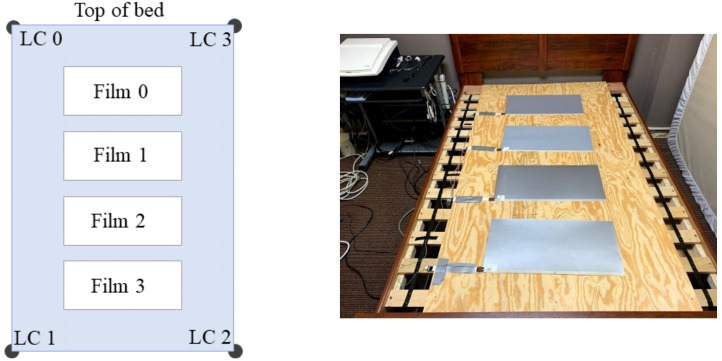

In [7]:

#Image of bed sensor system
#disp_img.Image("/home/imelna/data_files/BCG_Research/CinC2022_BCG_PTT_PAPER_NOTEBOOKS/bed_sensor_system.jpg")

In [7]:

# example of a dictionary with the key being sub1 and the value being a dataframe with the columns we wanted to keep after downsampling to 200 hz
display (data_dict["sub1"])

,ECG,Film0,Film1,Film2,Film3,LC_BCG0,LC_BCG1,LC_BCG2,LC_BCG3
0,-0.155581,1.361716,1.456826,0.850984,1.699046,0.299792,-0.471540,-0.186368,0.749975
1,-0.197400,2.165784,1.297433,0.233342,0.815010,0.299295,0.068727,0.027791,0.636647
2,-0.188681,0.724704,0.740686,-1.389769,-1.046557,0.301692,0.246596,0.247410,0.748925
3,-0.188145,1.465041,1.146419,-0.473800,0.586544,0.381479,0.528997,0.445333,0.774234
4,-0.188602,2.285431,1.766004,1.030310,1.628976,0.570517,0.694827,0.587884,0.863358
...,...,...,...,...,...,...,...,...,...
59795,-0.094830,-1.566327,0.427230,-1.376465,-1.337994,-0.242601,-1.438427,-0.716076,0.796371
59796,-0.101302,-0.354894,1.198113,0.438273,1.159481,-0.048031,-1.236653,-0.568303,1.001253
59797,-0.088656,-0.079142,1.487548,1.116990,1.127357,0.110005,-1.506717,-0.561466,1.044480
59798,-0.099160,-1.211433,0.770492,-0.784857,-1.183004,0.168084,-1.317654,-0.534788,1.074596


In [19]:
# The columns we want to use for our example
# These represent the ECG signal captures from each signal
# as well as the BCG signal captured from each sensor under the mattress
from glob import glob

my_columns=["ECG",'Film0', 'Film1', 'Film2', 'Film3','LC_BCG0','LC_BCG1','LC_BCG2','LC_BCG3']

#LOAD PATHS
################ CHANGE PATH TO WHERE YOUR BCG DATA FOLDER IS LOCATED ################
path="bcg_exercise_data/*.csv"


#PARSE TO DICT
orig_Fs=1000 #original sampling frequency
new_Fs=200 # new sampling frequency 
# ADD CODE HERE # 


# Get all csv files from folder
file_list = glob(path)

# Downsampling factor
decimation_factor = int(orig_Fs / new_Fs)

# Design 100 Hz low-pass Butterworth filter
cutoff = 100  # Hz
nyquist = orig_Fs / 2
normal_cutoff = cutoff / nyquist
b, a = signal.butter(4, normal_cutoff, btype='low')

# Dictionary to store processed data
data_dict = {}

for file in file_list:
    
    # Extract subject ID (e.g., sub1)
    subject_id = os.path.basename(file).replace(".csv", "")
    
    # Load data
    df = pd.read_csv(file)
    
    # Keep only required columns
    df = df[my_columns]
    
    # Create dataframe for processed signals
    processed_df = pd.DataFrame()
    
    for col in my_columns:
        
        # Apply anti-aliasing filter
        filtered_signal = signal.filtfilt(b, a, df[col])
        
        # Downsample from 1000 Hz to 200 Hz
        downsampled_signal = filtered_signal[::decimation_factor]
        
        processed_df[col] = downsampled_signal
    
    # Store in dictionary
    data_dict[subject_id] = processed_df

print("Subjects loaded and processed:")
print(data_dict.keys())



Subjects loaded and processed:
dict_keys(['sub1', 'sub14', 'sub19', 'sub23', 'sub26', 'sub3', 'sub33'])


 
#### Example plots of the ECG signal, and one signal from each type of BCG sensor under the mattress

### Student Code for Task1 PART A AND B using Sub14 and sub26


Running for sub14
Mean ECG HR for this 4 second segment: 60.00 BPM


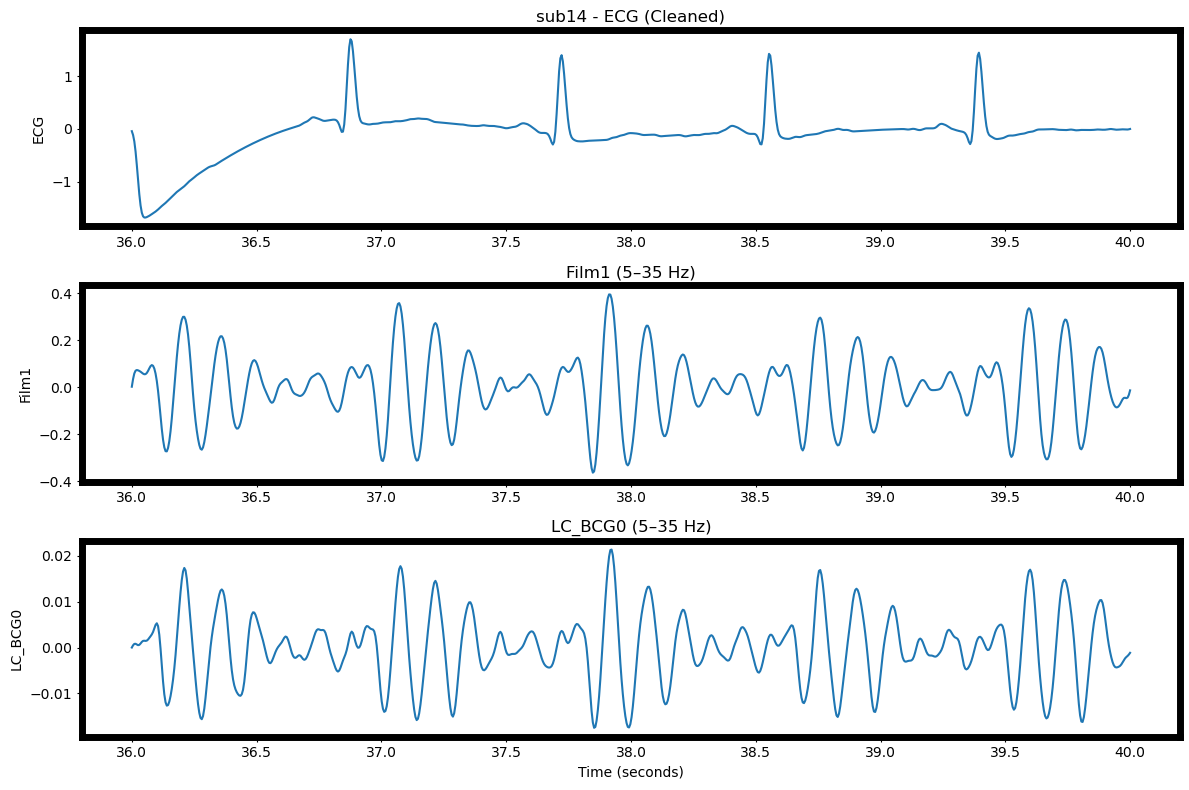


Running for sub26
Mean ECG HR for this 4 second segment: 60.00 BPM


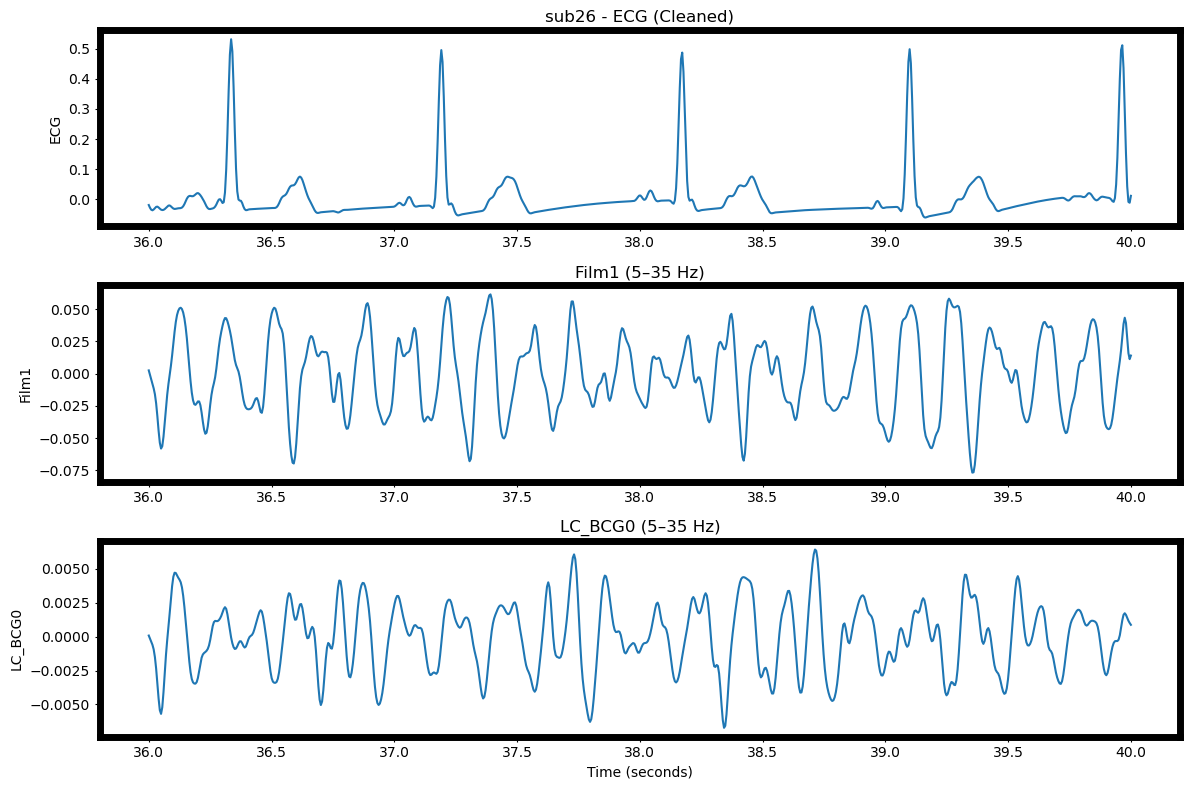

In [21]:

#SAMPLING FREQUENCY
Fs=200

#time window to use, 4 seconds of signal
t1=Fs*36
t2=Fs*40
# so we are using the 4 second window from the 36th to the 40th second of signal
############################################################



subjects_to_use = ["sub14", "sub26"]

# Bandpass filter design for BCG (5–35 Hz)
lowcut = 5
highcut = 35
nyquist = Fs / 2
b_band, a_band = signal.butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')

for subject in subjects_to_use:
    
    print(f"\nRunning for {subject}")
    
    df = data_dict[subject]
    
    # Extract 4-second segment (36s to 40s)
    ecg_segment = df["ECG"].iloc[t1:t2].values
    film1_segment = df["Film1"].iloc[t1:t2].values
    lc_bcg_segment = df["LC_BCG0"].iloc[t1:t2].values
    
    # Clean ECG signal
    ecg_cleaned = nk.ecg_clean(ecg_segment, sampling_rate=Fs)
    
    # Bandpass filter BCG signals (5–35 Hz)
    film1_filtered = signal.filtfilt(b_band, a_band, film1_segment)
    lc_bcg_filtered = signal.filtfilt(b_band, a_band, lc_bcg_segment)
    
    # Detect R-peaks properly
    signals, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=Fs)
    r_peak_indices = info["ECG_R_Peaks"]
    
    # Calculate heart rate
    num_beats = len(r_peak_indices)
    duration_sec = 4
    hr = (num_beats / duration_sec) * 60
    
    print(f"Mean ECG HR for this 4 second segment: {hr:.2f} BPM")
    
    # Time axis for plotting
    time_axis = np.linspace(36, 40, len(ecg_segment))
    
    # Plot signals
    plt.figure(figsize=(12,8))
    
    plt.subplot(3,1,1)
    plt.plot(time_axis, ecg_cleaned)
    plt.title(f"{subject} - ECG (Cleaned)")
    plt.ylabel("ECG")
    
    plt.subplot(3,1,2)
    plt.plot(time_axis, film1_filtered)
    plt.title("Film1 (5–35 Hz)")
    plt.ylabel("Film1")
    
    plt.subplot(3,1,3)
    plt.plot(time_axis, lc_bcg_filtered)
    plt.title("LC_BCG0 (5–35 Hz)")
    plt.ylabel("LC_BCG0")
    plt.xlabel("Time (seconds)")
    
    plt.tight_layout()
    plt.show()

In [27]:
print(len(r_peak_indices))


4


The BCG signals from the two subjects differ in amplitude, waveform shape, and overall clarity. These differences may result from variations in body weight, posture, mattress interaction, and movement during recording. Since BCG captures mechanical vibrations rather than direct electrical activity like ECG, it is more sensitive to noise and individual differences. This variability can make peak detection less consistent and therefore makes heart rate estimation from BCG more challenging.

In [22]:
#################### Part A Code: #################### 

#################### fix/fill in missing parts to get the below code working ####################

Fs = 200  # sampling frequency
epochlen = Fs * 4  # epoch length 

# initiate a dictionary to hold the results
ecg_hr_array_dict = dict()

for p in data_dict.keys():

    print("Running for {0}".format(p))
    
    # initiate empty list for the nested dictionary 
    ecg_hr_array_dict[p] = {"ECG_HR": []}
    
    # nk clean ecg
    ecg_cleaned = nk.ecg_clean(
        data_dict[p]["ECG"],
        sampling_rate=Fs,
        method="kalidas2017"
    )

    # detect r_peaks in the entire signals
    r_peaks = nk.ecg_findpeaks(
        ecg_cleaned,
        sampling_rate=200,
        method="kalidas2017"
    )
    r_peaks = r_peaks["ECG_R_Peaks"]
    
    # compute heart rate in 4 second windows from our r-peak array
    # we want to ignore the 1st second and the last 4 seconds of ECG/BCG signals
    time_stamps = np.arange(Fs, len(ecg_cleaned) - epochlen, epochlen)
    
    # we step through a time_stamps range
    for start_time in time_stamps:
        
        end_time = start_time + epochlen
        
        ######## FILL IN MISSING CODE ########
        
        # select R-peaks that fall within the current time window
        window_peaks = r_peaks[(r_peaks >= start_time) & (r_peaks < end_time)]
        
        # calculate RR intervals to then calculate the average heart rate
        if len(window_peaks) > 1:
            
            rr_intervals = np.diff(window_peaks) / Fs  # convert to seconds
            hr_values = 60 / rr_intervals              # convert to bpm
            avg_hr = np.mean(hr_values)
        
        else:
            avg_hr = np.nan
        
        # append the avg_hr result to the ECG_HR array for a given time window
        ecg_hr_array_dict[p]["ECG_HR"].append(avg_hr)
        
        ######## END OF FILLED CODE ########
    
    print("Mean HR for subject {0} = {1}".format(
        p, 
        np.nanmean(ecg_hr_array_dict[p]["ECG_HR"])
    ))


Running for sub1
Mean HR for subject sub1 = 42.049866268312954
Running for sub14
Mean HR for subject sub14 = 72.57048434924472
Running for sub19
Mean HR for subject sub19 = 54.19890947223242
Running for sub23
Mean HR for subject sub23 = 55.55333850587366
Running for sub26
Mean HR for subject sub26 = 70.22778479393023
Running for sub3
Mean HR for subject sub3 = 58.226430157869494
Running for sub33
Mean HR for subject sub33 = 87.09393837189832


In [30]:
#################### Part B Code: #################### 

#################### fix/fill in missing parts to get the below code working ####################
fhp=5 #highpass filter value
flp=35 #lowpass filter value
my_scales=scale_selecter(scales=(fhp,flp,1),fs=200)
Fs=200 #sampling frequency
epochlen=Fs*4 #epoch length 

def normalize_sig(sig):
    sig = np.array(sig)
    return (sig - np.min(sig)) / (np.max(sig) - np.min(sig) + 1e-8)


#initiate a dictionary to hold the results
bcg_hr_array_dict=dict()

#for p in ["sub14"]:
for p in data_dict.keys():
    print("Running for {0}".format(p))
    
    #initiate key-value
    bcg_hr_array_dict[p]={key: 0  for key in ['Film0', 'Film1', 'Film2', 'Film3','LC_BCG0','LC_BCG1','LC_BCG2','LC_BCG3']}
    
    for axz in ['Film0', 'Film1', 'Film2', 'Film3','LC_BCG0','LC_BCG1','LC_BCG2','LC_BCG3']:
        
        
        
        #initiate empty list for the nested dictionary 
        bcg_hr_array_dict[p][axz]={key: []  for key in ["HR_array"]}
        
        #band pass filter bcg signal between 5 and 35 hz
        bcg_cleaned=bp_filter(data_dict[p][axz],hp=5,lp=35,fs=Fs,order=4)
        
        #range for 4 second windows
        startposvec = np.arange(Fs,len(bcg_cleaned)-epochlen,epochlen)
        
        for startpos in startposvec:
            
            windowed_bcg_signal=bcg_cleaned[startpos-Fs : startpos+epochlen+Fs]
            
            my_cwt,f=cwt_waveform_maker(windowed_bcg_signal,my_scales,wavelet_name="morl",fs=200,abs_val=True)
            
            ######## FILL IN MISSING CODE in this loop ########
            
            smooth_window_50ms = int(0.05 * Fs)
            my_stat_wav = cwt_stat_waveform(my_cwt, smoothwindow=smooth_window_50ms)
            
            my_stat_wav = my_stat_wav[Fs:-Fs]
            
            my_signal = normalize_sig(my_stat_wav)
            
            my_signal = np.gradient(my_signal)
            
            smooth_window_100ms = int(0.1 * Fs)
            my_signal = rollingmedian(my_signal, window=smooth_window_100ms)
            
            my_signal = normalize_sig(my_signal)
            
            xc = signal.correlate(my_signal, my_signal)
            xc = xc[len(my_signal):]
            
            HR_ESTIMATE = auto_corr_hr_detector(xc)
            
            bcg_hr_array_dict[p][axz]["HR_array"].append(HR_ESTIMATE)
            
            ######## END OF FILLED CODE ########
        
        # SHOW NUMERIC VALUE
        mean_hr = np.nanmean(bcg_hr_array_dict[p][axz]["HR_array"])
        print(f"{axz} mean HR = {mean_hr:.2f}")



Running for sub1
Film0 mean HR = 46.21
Film1 mean HR = 64.10
Film2 mean HR = 98.70
Film3 mean HR = 99.60
LC_BCG0 mean HR = 83.78
LC_BCG1 mean HR = 53.25
LC_BCG2 mean HR = 45.23
LC_BCG3 mean HR = 69.86
Running for sub14
Film0 mean HR = 74.20
Film1 mean HR = 74.17
Film2 mean HR = 148.70
Film3 mean HR = 114.28
LC_BCG0 mean HR = 74.12
LC_BCG1 mean HR = 76.60
LC_BCG2 mean HR = 99.91
LC_BCG3 mean HR = 74.19
Running for sub19
Film0 mean HR = 100.77
Film1 mean HR = 57.27
Film2 mean HR = 113.30
Film3 mean HR = 57.32
LC_BCG0 mean HR = 58.06
LC_BCG1 mean HR = 71.98
LC_BCG2 mean HR = 55.27
LC_BCG3 mean HR = 88.15
Running for sub23
Film0 mean HR = 61.37
Film1 mean HR = 109.60
Film2 mean HR = 97.08
Film3 mean HR = 101.69
LC_BCG0 mean HR = 63.50
LC_BCG1 mean HR = 102.58
LC_BCG2 mean HR = 76.83
LC_BCG3 mean HR = 110.60
Running for sub26
Film0 mean HR = 140.43
Film1 mean HR = 105.80
Film2 mean HR = 113.84
Film3 mean HR = 107.13
LC_BCG0 mean HR = 125.31
LC_BCG1 mean HR = 85.37
LC_BCG2 mean HR = 75.00
LC

#### PART C Code 

For each subject, calculate the Median Absolute Error (MAE) vs the heart rate array for each of the eight BCG channels. Report the name of the channel which produces the minimum MAE.

For each subject, plot the ECG heart rate array and the heart rate array of the BCG channel that produced the lowest MAE.


Running for subject: sub1
Best channel: Film0
Minimum MAE: 2.238909942034084


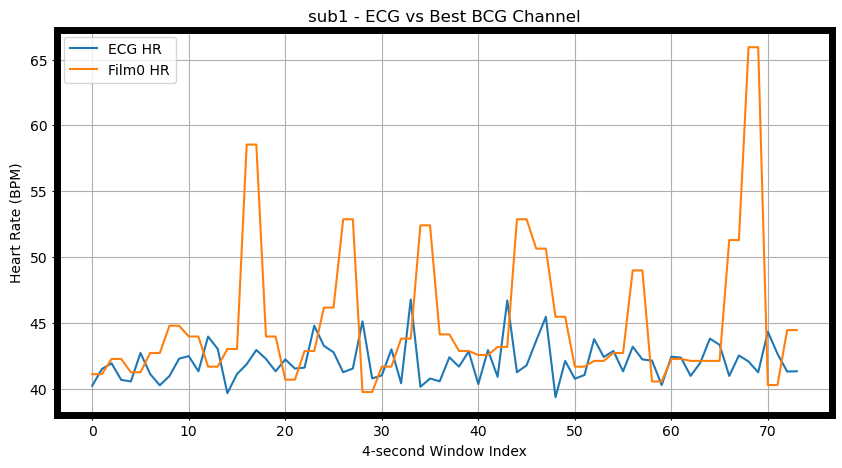


Running for subject: sub14
Best channel: LC_BCG0
Minimum MAE: 3.9943957661173357


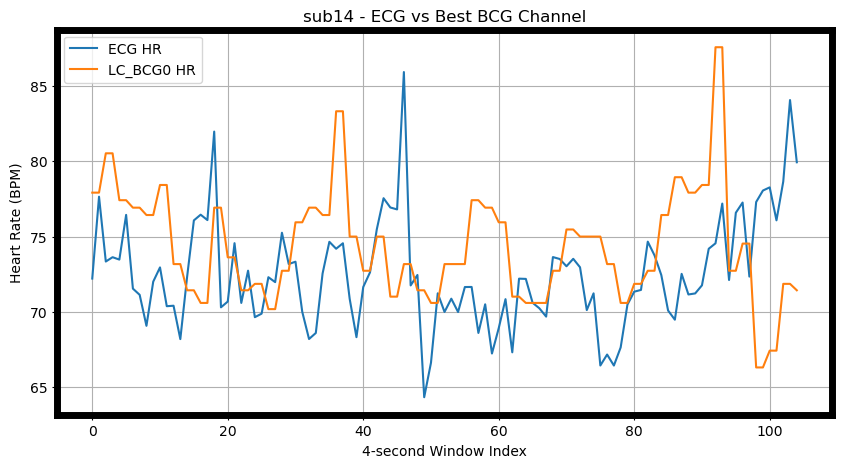


Running for subject: sub19
Best channel: LC_BCG2
Minimum MAE: 1.7088002924050727


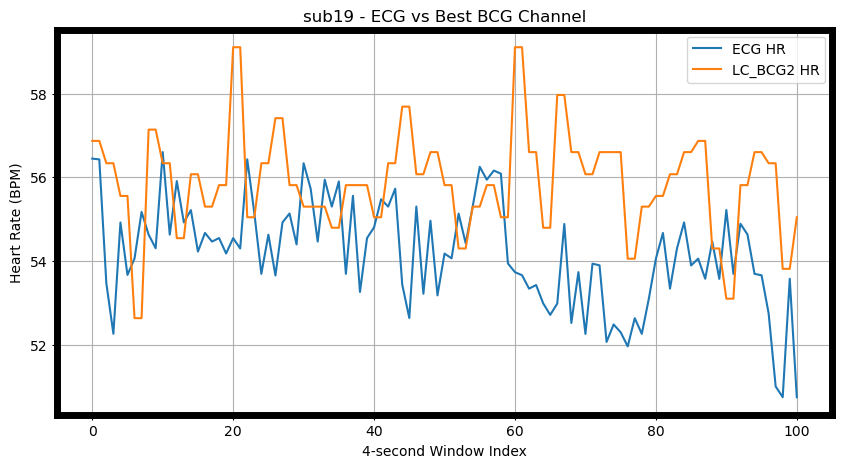


Running for subject: sub23
Best channel: Film0
Minimum MAE: 3.9234445605322747


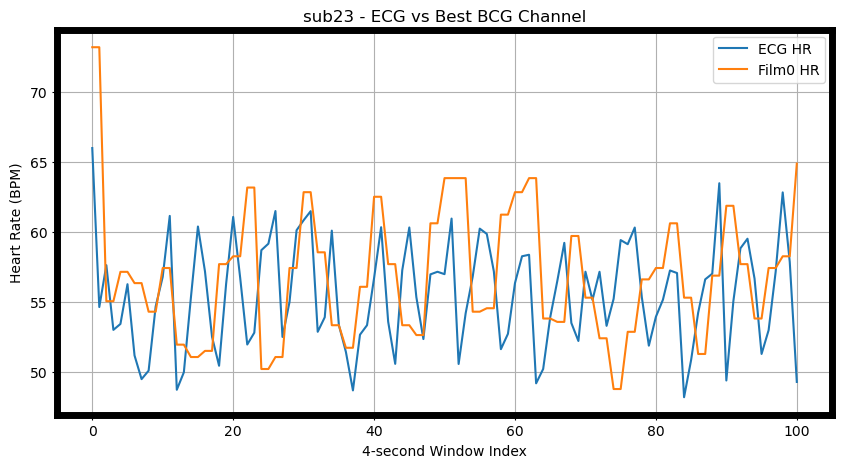


Running for subject: sub26
Best channel: LC_BCG1
Minimum MAE: 3.4779332480285206


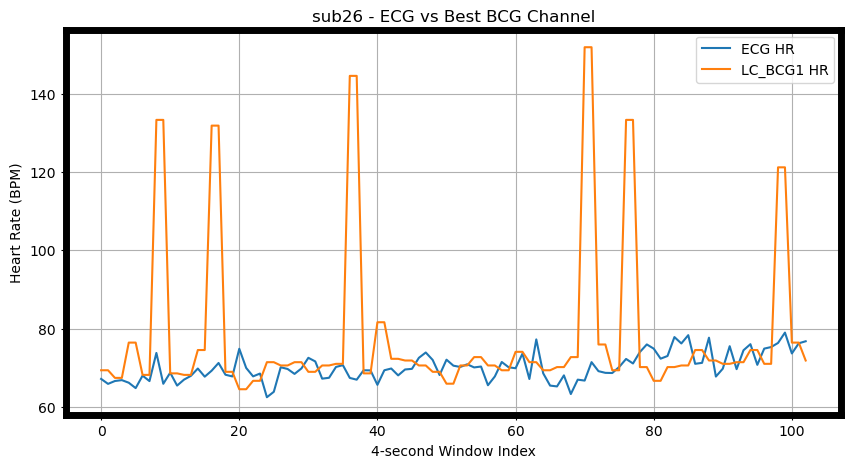


Running for subject: sub3
Best channel: LC_BCG2
Minimum MAE: 2.999013640628384


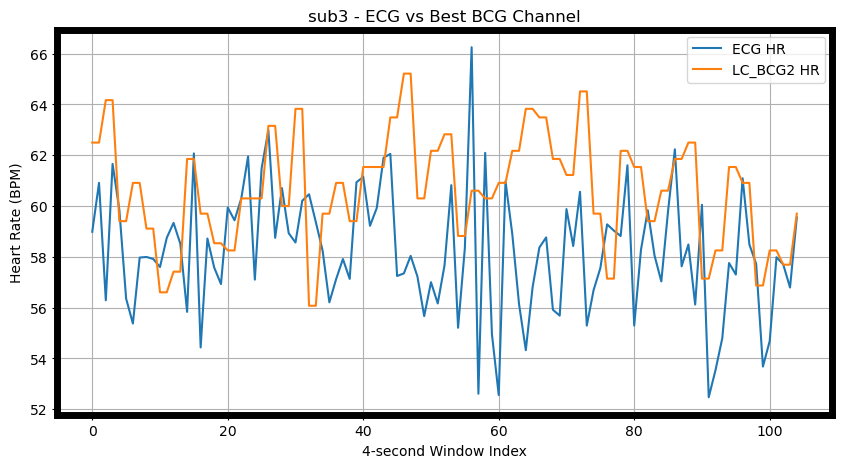


Running for subject: sub33
Best channel: Film1
Minimum MAE: 3.545620314716018


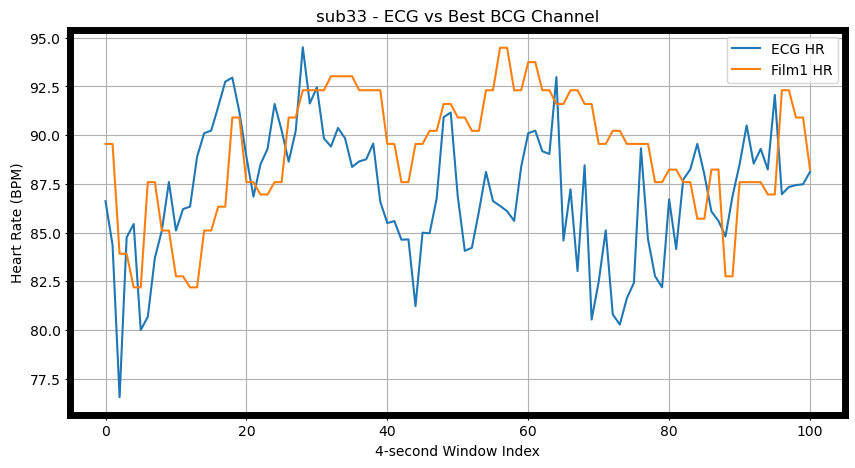

In [26]:
# plot the ECG with the BCG channel that produced the lowest MAE for each subject

#code cell

from sklearn.metrics import median_absolute_error
import matplotlib.pyplot as plt
import numpy as np

for p in data_dict.keys():
    
    print("\nRunning for subject:", p)
    
    ecg_hr = np.array(ecg_hr_array_dict[p]["ECG_HR"])
    
    mae_dict = {}
    
    # Compare ECG HR with each BCG channel
    for ch in ['Film0', 'Film1', 'Film2', 'Film3',
               'LC_BCG0', 'LC_BCG1', 'LC_BCG2', 'LC_BCG3']:
        
        bcg_hr = np.array(bcg_hr_array_dict[p][ch]["HR_array"])
        
        # Make sure lengths match
        min_len = min(len(ecg_hr), len(bcg_hr))
        ecg_trim = ecg_hr[:min_len]
        bcg_trim = bcg_hr[:min_len]
        
        mae = median_absolute_error(ecg_trim, bcg_trim)
        mae_dict[ch] = mae
    
    # Find channel with lowest MAE
    best_channel = min(mae_dict, key=mae_dict.get)
    
    print("Best channel:", best_channel)
    print("Minimum MAE:", mae_dict[best_channel])
    
    # Plot ECG HR vs best BCG HR
    best_bcg_hr = np.array(bcg_hr_array_dict[p][best_channel]["HR_array"])
    min_len = min(len(ecg_hr), len(best_bcg_hr))
    
    plt.figure(figsize=(10,5))
    plt.plot(ecg_hr[:min_len], label="ECG HR")
    plt.plot(best_bcg_hr[:min_len], label=f"{best_channel} HR")
    plt.title(f"{p} - ECG vs Best BCG Channel")
    plt.xlabel("4-second Window Index")
    plt.ylabel("Heart Rate (BPM)")
    plt.legend()
    plt.grid()
    plt.show()


#### Part D Questions

Question:

* Does the same channel produce the lowest MAE when compared to the HR produced by the ECG for each subject, if not why do you think it might not?
* What are some possible pros and cons of using a bed based BCG system compared to a typical 1-lead ECG for HR monitoring in patients when they are laying in a bed?
* What demographic in your opinion could benefit the most from non-invasive monitoring systems like a bed-based BCG heart monitoring system? 

Question answers here 
Answer 1: No, the same channel does not produce the lowest MAE for all subjects. This is because BCG signals depend on how the body’s mechanical vibrations are transmitted through the mattress and detected by the sensors. Factors such as body weight distribution, sleeping posture, mattress stiffness, and sensor placement can affect signal quality differently for each subject. As a result, certain channels may capture stronger or cleaner cardiac vibrations for one subject but not for another.

Answer 2: A major advantage of a bed-based BCG system is that it is completely non-invasive and does not require electrodes attached to the skin, making it more comfortable for long-term monitoring. It is also suitable for continuous overnight monitoring without disturbing the patient. However, BCG signals are more sensitive to motion artifacts and environmental noise, and they do not provide detailed electrical information about the heart like ECG does. Therefore, ECG remains more accurate and reliable for clinical diagnosis.

Answer 3: Elderly individuals and patients requiring long-term monitoring, such as those with cardiovascular conditions or sleep disorders, would benefit the most from non-invasive systems like bed-based BCG. These systems allow continuous heart rate monitoring without discomfort or the need for frequent electrode replacement. They are also particularly useful in home-care settings where unobtrusive and easy-to-use monitoring solutions are important.